In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgs
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ── Paleta visual oscura ─────────────────────────────────────────
BG   = "#030b15"   # fondo negro azulado
BG2  = "#06101e"   # fondo paneles
GC   = "#0b1d35"   # bordes
TC   = "#2563a8"   # texto azul principal

TCOV = LinearSegmentedColormap.from_list("cov", [(0, BG), (0.4, "#0c2855"), (1, "#38bdf8")])
TALM = LinearSegmentedColormap.from_list("alm", [(0, BG), (0.5, "#3a0808"), (1, "#f87171")])

COL = {"ga": "#f87171", "aco": "#22d3ee", "rnd": "#64748b"}
LBL = {"ga": "GA Multi-entorno", "aco": "ACO (params. manuales)", "rnd": "Movimiento aleatorio"}

def sax(ax, bg=BG2):
    """Aplicar estilo oscuro a un eje."""
    ax.set_facecolor(bg)
    for s in ax.spines.values():
        s.set_color(GC)
    ax.tick_params(colors="#1a3a5c", labelsize=8)
    ax.xaxis.label.set_color(TC)
    ax.yaxis.label.set_color(TC)

print("✓ Librerías cargadas")

✓ Librerías cargadas


In [3]:
# ── Mundo ────────────────────────────────────────────────────────
GRID     = 60       # tamaño del mapa en celdas (60×60)
N_DRONES = 6        # número de drones en la misión
N_VICT   = 10       # víctimas ocultas a localizar
T_MAX    = 350      # pasos de tiempo por simulación
SX, SY   = GRID//2, GRID//2   # punto de salida (centro del mapa)

# ── Sensor ───────────────────────────────────────────────────────
# Fijo para todos los algoritmos (sin trampa de "sensor gigante")
SENSOR_R = 2.0      # radio de detección en celdas

# ── Genoma ───────────────────────────────────────────────────────
# Son SOLO 7 números. El mapa tiene 3600 celdas.
# → Imposible memorizar el mapa en 7 números.
N_GENES = 7
GENE_NAMES  = ["Huir rastro", "Seguir alarma", "Repulsión",
               "Cohesión", "Ruido", "Sesgo giro", "Inercia"]
GENE_COLORS = ["#38bdf8", "#f87171", "#fb923c", "#4ade80",
               "#a78bfa", "#fbbf24", "#60a5fa"]

# ── Algoritmo Genético ───────────────────────────────────────────
GA_GENS       = 20    # generaciones
GA_POP        = 36    # individuos por generación
GA_ELITE      = 4     # mejores que pasan directo (elitismo)
MAPS_PER_EVAL = 5     # mapas DISTINTOS por evaluación (anti-overfitting)

# ── Seeds ────────────────────────────────────────────────────────
# El GA entrena con seeds 0–499, NUNCA ve los de test
TRAIN_SEED_RANGE = (0, 500)
TEST_SEEDS = [600, 650, 700, 750, 800, 850, 900, 950,
              601, 651, 701, 751, 801, 851, 901]

# ACO con parámetros elegidos a mano (baseline)
ACO_GENOME = np.array([0.70, 0.0, 0.35, 0.0, 0.50, 0.0, 0.40])

print(f"✓ Parámetros definidos")
print(f"  Mapa: {GRID}×{GRID} = {GRID*GRID} celdas de información")
print(f"  Genoma: {N_GENES} números → {N_GENES/GRID**2*100:.4f}% del tamaño del mapa")
print(f"  → El genoma NO puede contener información del mapa")


✓ Parámetros definidos
  Mapa: 60×60 = 3600 celdas de información
  Genoma: 7 números → 0.1944% del tamaño del mapa
  → El genoma NO puede contener información del mapa


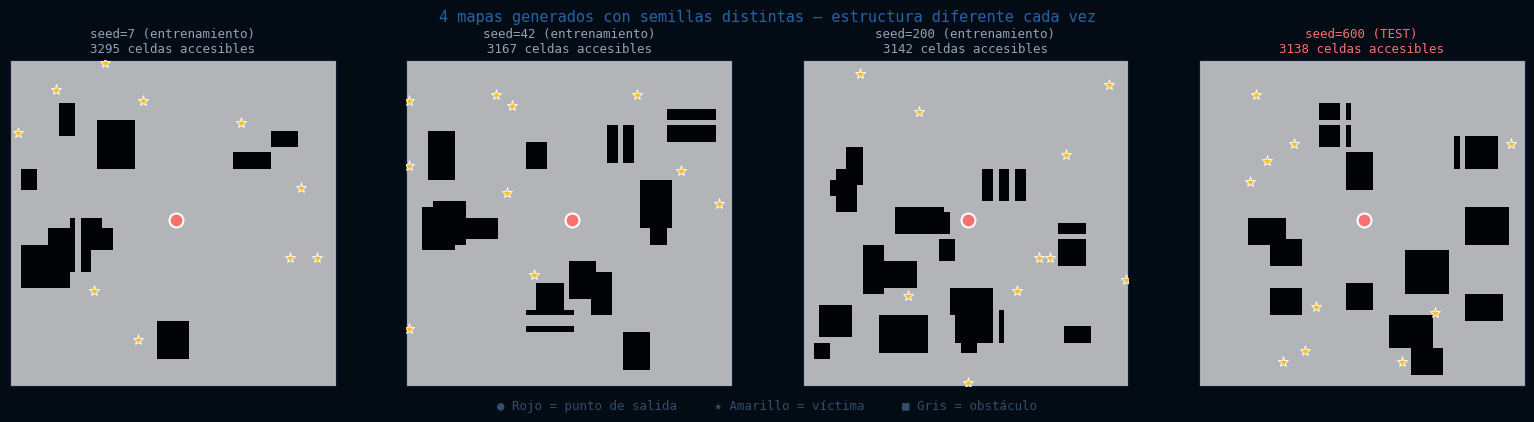

In [4]:
_map_cache = {}   # guardamos mapas ya generados para no repetir trabajo

def build_map(seed):
    """
    Genera un mapa de misión urbana.

    El mismo seed siempre da el mismo mapa.
    Seeds distintos dan mapas estructuralmente diferentes.

    Devuelve: (grid, total_accesible, lista_de_victimas)
    """
    if seed in _map_cache:
        return _map_cache[seed]

    rng = np.random.RandomState(seed)
    grid = np.zeros((GRID, GRID), dtype=np.int8)

    # 1. Bloques de escombros/edificios
    for _ in range(rng.randint(8, 18)):
        x, y = rng.randint(2, GRID-10), rng.randint(2, GRID-10)
        w, h = rng.randint(3, 10),      rng.randint(3, 10)
        grid[y:y+h, x:x+w] = 1

    # 2. Corredores variados (distinta posición en cada mapa)
    for _ in range(rng.randint(1, 4)):
        grid[rng.randint(5, GRID-5), :] = 0
    for _ in range(rng.randint(1, 4)):
        grid[:, rng.randint(5, GRID-5)] = 0

    # 3. Zona de salida libre (centro)
    grid[SY-3:SY+4, SX-3:SX+4] = 0

    # 4. BFS: encontrar todas las celdas accesibles desde el centro
    accessible = np.zeros_like(grid, dtype=bool)
    queue = [(SX, SY)]
    accessible[SY, SX] = True
    while queue:
        cx, cy = queue.pop()
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = cx+dx, cy+dy
            if 0<=nx<GRID and 0<=ny<GRID and not grid[ny,nx] and not accessible[ny,nx]:
                accessible[ny, nx] = True
                queue.append((nx, ny))

    total_acc = int(accessible.sum())
    if total_acc < 600:          # mapa demasiado bloqueado → fallback
        result = build_map(seed + 10000)
        _map_cache[seed] = result
        return result

    # 5. Colocar víctimas lejos del centro (más difíciles de encontrar)
    ys, xs = np.where(accessible)
    far = np.hypot(xs - SX, ys - SY) > GRID * 0.20
    fxs, fys = xs[far], ys[far]
    if len(fxs) < N_VICT:
        fxs, fys = xs, ys
    idx = rng.choice(len(fxs), min(N_VICT, len(fxs)), replace=False)
    victims = [{"x": int(fxs[i]), "y": int(fys[i]), "found": False} for i in idx]

    result = (grid, total_acc, victims)
    _map_cache[seed] = result
    return result


# ── Visualizar 4 mapas distintos ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor=BG)
fig.suptitle("4 mapas generados con semillas distintas — estructura diferente cada vez",
             color=TC, fontsize=11, fontfamily="monospace")

for ax, seed in zip(axes, [7, 42, 200, 600]):
    grid, total_acc, victims = build_map(seed)
    ax.set_facecolor("#040b14")
    ax.imshow(grid, cmap=plt.cm.Greys, origin="lower", vmin=0, vmax=1, alpha=0.7)
    # marcar víctimas
    for v in victims:
        ax.plot(v["x"], v["y"], "*", color="#fbbf24", ms=8, mew=0.6, mec="white", zorder=5)
    # marcar base
    ax.plot(SX, SY, "o", color="#f87171", ms=10, mew=1.5, mec="white", zorder=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_color(GC)
    seed_type = "entrenamiento" if seed < 500 else "TEST"
    ax.set_title(f"seed={seed} ({seed_type})\n{total_acc} celdas accesibles",
                 color="#94a3b8" if seed < 500 else "#f87171",
                 fontsize=9, fontfamily="monospace")

fig.text(0.5, -0.02,
         "● Rojo = punto de salida     ★ Amarillo = víctima     ■ Gris = obstáculo",
         ha="center", color="#334e6b", fontsize=9, fontfamily="monospace")
plt.tight_layout()
plt.show()


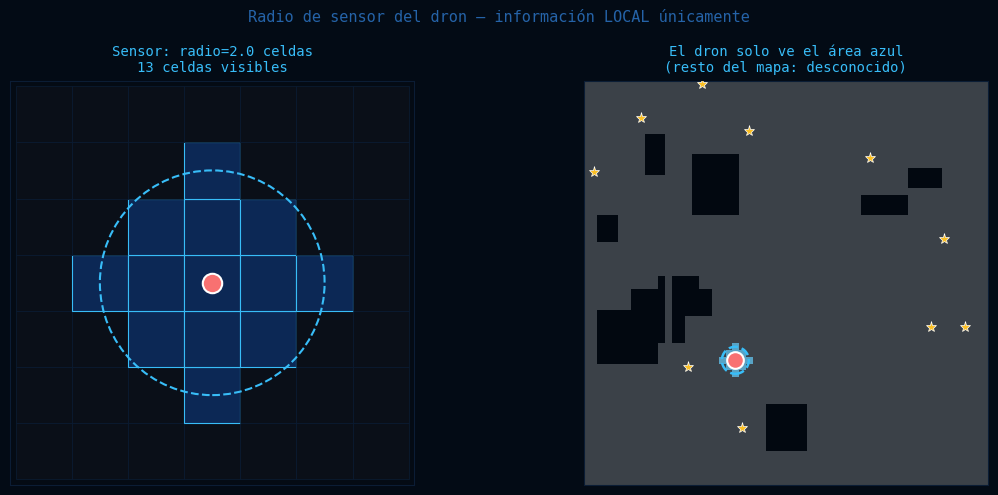

El dron ve 13 de 3600 celdas = 0.4% del mapa


In [5]:
# Precalcular las celdas dentro del radio del sensor
SENSOR_OFFSETS = [
    (dy, dx) for dy in range(-4, 5) for dx in range(-4, 5)
    if dx*dx + dy*dy <= SENSOR_R * SENSOR_R
]

# ── Visualizar el sensor ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)
fig.suptitle("Radio de sensor del dron — información LOCAL únicamente",
             color=TC, fontsize=11, fontfamily="monospace")

# Panel izquierdo: el sensor en abstracto
ax = axes[0]
ax.set_facecolor("#040b14")
for sp in ax.spines.values(): sp.set_color(GC)

# dibujar todas las celdas del radio
r_int = int(SENSOR_R) + 1
mini_grid = np.zeros((2*r_int+1, 2*r_int+1))
sensor_cells = set()
for dy, dx in SENSOR_OFFSETS:
    if -r_int <= dy <= r_int and -r_int <= dx <= r_int:
        sensor_cells.add((dy+r_int, dx+r_int))

for row in range(2*r_int+1):
    for col in range(2*r_int+1):
        dist = np.hypot(col-r_int, row-r_int)
        if (row, col) in sensor_cells:
            rect = plt.Rectangle([col-0.5, row-0.5], 1, 1,
                                   facecolor="#0c2855", edgecolor="#38bdf8", linewidth=0.8)
        else:
            rect = plt.Rectangle([col-0.5, row-0.5], 1, 1,
                                   facecolor="#0a0f18", edgecolor=GC, linewidth=0.5)
        ax.add_patch(rect)

ax.plot(r_int, r_int, "o", color="#f87171", ms=14, mew=1.5, mec="white", zorder=5)
circle = plt.Circle((r_int, r_int), SENSOR_R, fill=False, color="#38bdf8", lw=1.5, ls="--")
ax.add_patch(circle)
ax.set_xlim(-0.6, 2*r_int+0.6); ax.set_ylim(-0.6, 2*r_int+0.6)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Sensor: radio={SENSOR_R} celdas\n{len(SENSOR_OFFSETS)} celdas visibles",
             color="#38bdf8", fontsize=10, fontfamily="monospace")

# Panel derecho: el sensor en contexto de un mapa real
ax2 = axes[1]
grid, total_acc, victims = build_map(7)
ax2.set_facecolor("#040b14")
for sp in ax2.spines.values(): sp.set_color(GC)
ax2.imshow(grid, cmap=plt.cm.Greys, origin="lower", vmin=0, vmax=1, alpha=0.5)

# posición ficticia del dron
dx_pos, dy_pos = 22, 18

# zona visible
visible_mask = np.zeros((GRID, GRID))
for dy, dx_o in SENSOR_OFFSETS:
    nx, ny = dx_pos+dx_o, dy_pos+dy
    if 0 <= nx < GRID and 0 <= ny < GRID:
        visible_mask[ny, nx] = 1

ax2.imshow(visible_mask, origin="lower", cmap=TCOV, alpha=0.55, zorder=2)
ax2.plot(dx_pos, dy_pos, "o", color="#f87171", ms=12, mew=1.5, mec="white", zorder=6)
circle2 = plt.Circle((dx_pos, dy_pos), SENSOR_R, fill=False,
                       color="#38bdf8", lw=1.8, ls="--", zorder=5)
ax2.add_patch(circle2)

for v in victims:
    ax2.plot(v["x"], v["y"], "*", color="#fbbf24", ms=8, mew=0.5, mec="w", zorder=4)

ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title(f"El dron solo ve el área azul\n(resto del mapa: desconocido)",
               color="#38bdf8", fontsize=10, fontfamily="monospace")

plt.tight_layout()
plt.show()
print(f"El dron ve {len(SENSOR_OFFSETS)} de {GRID*GRID} celdas = {len(SENSOR_OFFSETS)/GRID**2*100:.1f}% del mapa")


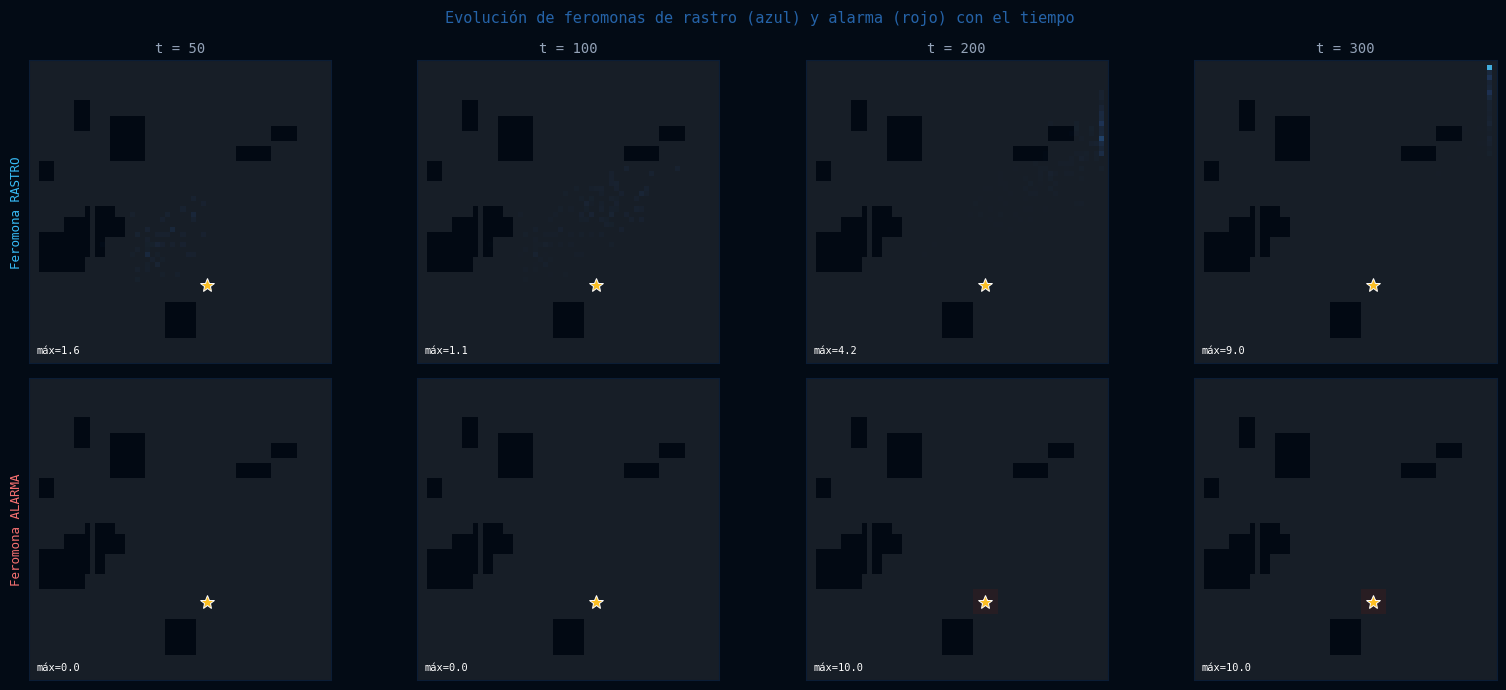

Las feromonas permiten coordinación SIN comunicación directa


In [6]:
# Visualizar cómo evolucionan las feromonas en el tiempo

fig, axes = plt.subplots(2, 4, figsize=(16, 7), facecolor=BG)
fig.suptitle("Evolución de feromonas de rastro (azul) y alarma (rojo) con el tiempo",
             color=TC, fontsize=11, fontfamily="monospace")

rng_demo = np.random.RandomState(0)

# Simular solo feromonas para ilustrar (sin física completa)
ptr_demo = np.zeros((GRID, GRID), dtype=np.float32)
pal_demo = np.zeros((GRID, GRID), dtype=np.float32)
grid_demo, _, _ = build_map(7)

# Posiciones ficticias de drones
drone_paths = [
    (20 + int(t*0.3), 20 + int(t*0.2)) for t in range(T_MAX)
]
victim_pos = (35, 15)   # víctima ficticia

snapshots = [50, 100, 200, 300]
snap_data = []

for t in range(T_MAX):
    ptr_demo *= 0.983
    pal_demo *= 0.976
    px = int(np.clip(20 + t*0.25 + rng_demo.randn()*3, 1, GRID-2))
    py = int(np.clip(20 + t*0.15 + rng_demo.randn()*3, 1, GRID-2))
    ptr_demo[py, px] = min(9., ptr_demo[py, px] + 0.7)
    # simular descubrimiento de víctima en t=120
    if t > 120:
        vx, vy = victim_pos
        pal_demo[vy, vx] = min(10., pal_demo[vy, vx] + 0.3)
        # difundir alarma
        for dy in range(-2, 3):
            for dx2 in range(-2, 3):
                nx2, ny2 = vx+dx2, vy+dy
                if 0<=nx2<GRID and 0<=ny2<GRID:
                    pal_demo[ny2, nx2] = min(10., pal_demo[ny2, nx2] + 0.05)
    if (t+1) in snapshots:
        snap_data.append((t+1, ptr_demo.copy(), pal_demo.copy()))

for col, (t_snap, ptr_s, pal_s) in enumerate(snap_data):
    for row, (data, cmap, title, vmax) in enumerate([
        (ptr_s, TCOV, "Feromona RASTRO (azul)", 9),
        (pal_s, TALM, "Feromona ALARMA (rojo)", 10)
    ]):
        ax = axes[row, col]
        ax.set_facecolor("#040b14")
        for sp in ax.spines.values(): sp.set_color(GC)
        ax.imshow(grid_demo, cmap=plt.cm.Greys, origin="lower", vmin=0, vmax=1, alpha=0.4)
        ax.imshow(data/vmax, origin="lower", cmap=cmap, alpha=0.8, vmin=0, vmax=1)
        ax.plot(victim_pos[0], victim_pos[1], "*", color="#fbbf24", ms=10, mew=0.7,
                mec="w", zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f"t = {t_snap}", color="#94a3b8",
                          fontsize=10, fontfamily="monospace")
        if col == 0:
            ax.set_ylabel(title.split("(")[0].strip(), color="#38bdf8" if row==0 else "#f87171",
                           fontsize=9, fontfamily="monospace")
        # anotar max
        ax.text(1, 1, f"máx={data.max():.1f}", color="white", fontsize=7.5,
                fontfamily="monospace", va="bottom", zorder=6)

plt.tight_layout()
plt.show()
print("Las feromonas permiten coordinación SIN comunicación directa")


In [8]:
def simulate(genome, map_seed, sim_seed=0, record=False, snap_at=None):
    """
    Simula T_MAX pasos de tiempo con el comportamiento definido por 'genome'.

    genome:   array de 7 genes [0, 1] que pesan cada comportamiento
    map_seed: semilla del mapa (determina obstáculos y posición de víctimas)
    sim_seed: semilla de aleatoriedad del movimiento
    record:   si True, guarda snapshots visuales en los tiempos snap_at

    Devuelve:
        curve_cov:  % de área cubierta en cada paso de tiempo
        curve_vic:  % de víctimas halladas en cada paso de tiempo
        snaps:      lista de snapshots (solo si record=True)
    """
    grid, total_acc, victims_tpl = build_map(map_seed)
    rng     = np.random.RandomState(sim_seed)
    angs    = np.linspace(0, 2*np.pi, N_DRONES, endpoint=False)
    pos     = np.column_stack([SX + np.cos(angs)*3, SY + np.sin(angs)*3])
    vel     = np.column_stack([np.cos(angs), np.sin(angs)])
    cov     = np.zeros((GRID, GRID), dtype=np.int16)
    ptr     = np.zeros((GRID, GRID), dtype=np.float32)   # feromona rastro
    pal     = np.zeros((GRID, GRID), dtype=np.float32)   # feromona alarma
    victims = [dict(v) for v in victims_tpl]

    # Extraer pesos del genoma
    w_fl, w_al, w_rp, w_co, w_no, w_tr, w_in = [float(x) for x in genome]

    vis = 0   # celdas visitadas por primera vez (cobertura)
    vf  = 0   # víctimas encontradas

    curve_cov = np.zeros(T_MAX)
    curve_vic = np.zeros(T_MAX)
    snaps     = []
    snap_at   = snap_at or set()

    for t in range(T_MAX):
        # Evaporación de feromonas
        ptr *= 0.983
        pal *= 0.976

        for i in range(N_DRONES):
            px, py = float(pos[i, 0]), float(pos[i, 1])
            gx = int(np.clip(round(px), 0, GRID-1))
            gy = int(np.clip(round(py), 0, GRID-1))
            fx = fy = 0.0

            # ── 1. Huir del rastro propio ──────────────────────────────
            cgx = int(np.clip(gx, 1, GRID-2))
            cgy = int(np.clip(gy, 1, GRID-2))
            dpx = float(ptr[cgy, cgx+1] - ptr[cgy, cgx-1])
            dpy = float(ptr[cgy+1, cgx] - ptr[cgy-1, cgx])
            dn  = max(np.hypot(dpx, dpy), 1e-6)
            fx -= dpx/dn * w_fl
            fy -= dpy/dn * w_fl

            # ── 2. Seguir feromona de alarma ───────────────────────────
            dax = float(pal[cgy, cgx+1] - pal[cgy, cgx-1])
            day = float(pal[cgy+1, cgx] - pal[cgy-1, cgx])
            an  = max(np.hypot(dax, day), 1e-6)
            fx += dax/an * w_al
            fy += day/an * w_al

            # ── 3. Repulsión + cohesión de vecinos ─────────────────────
            dif  = pos[i] - pos
            ds   = np.hypot(dif[:, 0], dif[:, 1])
            ds[i] = 1e9
            near = ds < 15
            if near.any():
                d2   = np.maximum(ds[near]**2, 0.25)
                fx  += (dif[near, 0] / d2 * w_rp).sum()
                fy  += (dif[near, 1] / d2 * w_rp).sum()
                mx   = pos[near, 0].mean() - px
                my   = pos[near, 1].mean() - py
                cn   = max(np.hypot(mx, my), 1e-6)
                fx  += mx/cn * w_co * 0.5
                fy  += my/cn * w_co * 0.5

            # ── 4. Inercia + sesgo de giro ─────────────────────────────
            vn = np.hypot(vel[i, 0], vel[i, 1])
            if vn > 0.01:
                fx += vel[i, 0]/vn * w_in
                fy += vel[i, 1]/vn * w_in
                fx += -vel[i, 1]/vn * w_tr * 0.28
                fy +=  vel[i, 0]/vn * w_tr * 0.28

            # ── 5. Ruido ───────────────────────────────────────────────
            fx += rng.randn() * (w_no * 1.5 + 0.06)
            fy += rng.randn() * (w_no * 1.5 + 0.06)

            # ── 6. Repulsión de paredes ────────────────────────────────
            m = 3
            if px < m:       fx += (m - px) * 0.5
            if px > GRID - m: fx -= (px - (GRID - m)) * 0.5
            if py < m:       fy += (m - py) * 0.5
            if py > GRID - m: fy -= (py - (GRID - m)) * 0.5

            # ── Mover ──────────────────────────────────────────────────
            n   = max(np.hypot(fx, fy), 1e-6)
            dx2, dy2 = fx/n, fy/n
            nx2 = float(np.clip(px + dx2, 0, GRID-1))
            ny2 = float(np.clip(py + dy2, 0, GRID-1))
            cx3 = int(round(nx2)); cy3 = int(round(ny2))
            if 0 <= cx3 < GRID and 0 <= cy3 < GRID and grid[cy3, cx3] == 0:
                pos[i, 0] = nx2; pos[i, 1] = ny2
                vel[i, 0] = dx2; vel[i, 1] = dy2
            else:
                for ddx, ddy in [(dy2, dx2), (-dy2, -dx2), (-dx2, -dy2)]:
                    tx = float(np.clip(px+ddx, 0, GRID-1))
                    ty = float(np.clip(py+ddy, 0, GRID-1))
                    tx2 = int(round(tx)); ty2 = int(round(ty))
                    if 0 <= tx2 < GRID and 0 <= ty2 < GRID and grid[ty2, tx2] == 0:
                        pos[i, 0] = tx; pos[i, 1] = ty
                        vel[i, 0] = ddx; vel[i, 1] = ddy
                        break
                else:
                    vel[i] *= -0.6

            # ── Depositar feromona + detectar ──────────────────────────
            cx4 = int(np.clip(round(pos[i, 0]), 0, GRID-1))
            cy4 = int(np.clip(round(pos[i, 1]), 0, GRID-1))
            ptr[cy4, cx4] = min(9., ptr[cy4, cx4] + 0.6)

            for dy3, dx3 in SENSOR_OFFSETS:
                sx2 = cx4 + dx3; sy2 = cy4 + dy3
                if 0 <= sx2 < GRID and 0 <= sy2 < GRID and grid[sy2, sx2] == 0:
                    if cov[sy2, sx2] == 0:
                        vis += 1
                    cov[sy2, sx2] = min(cov[sy2, sx2] + 1, 32767)

            for v in victims:
                if v["found"]:
                    continue
                if np.hypot(v["x"] - cx4, v["y"] - cy4) <= SENSOR_R:
                    v["found"] = True
                    vf += 1
                    pal[cy4, cx4] = min(10., pal[cy4, cx4] + 4.0)

        curve_cov[t] = min(100., vis / total_acc * 100.)
        curve_vic[t] = vf / len(victims) * 100.

        if record and (t+1) in snap_at:
            snaps.append({
                "t":       t + 1,
                "cov":     cov.copy(),
                "ptr":     ptr.copy(),
                "pal":     pal.copy(),
                "pos":     pos.copy(),
                "vel":     vel.copy(),
                "victims": [dict(vv) for vv in victims],
                "pc":      curve_cov[t],
                "pv":      curve_vic[t],
                "grid":    grid,
            })

    return curve_cov, curve_vic, snaps


# ── Test rápido ──────────────────────────────────────────────────
cc, cv, _ = simulate(ACO_GENOME, map_seed=7)
print(f"✓ Simulación correcta")
print(f"  Cobertura final (ACO fijo): {cc[-1]:.1f}%")
print(f"  Víctimas halladas:           {cv[-1]:.0f}%")


✓ Simulación correcta
  Cobertura final (ACO fijo): 70.4%
  Víctimas halladas:           60%


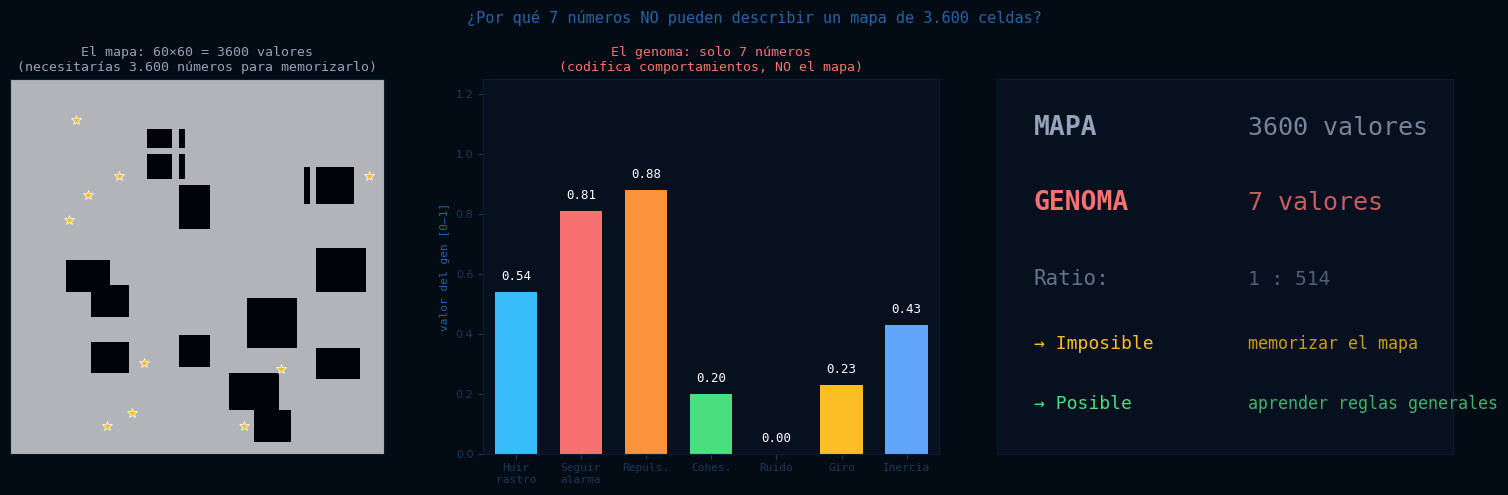

El genoma representa REGLAS DE COMPORTAMIENTO (pesos de reacción)
No representa DÓNDE ESTÁN los cosas en el mapa

Capacidad comparada:
  Mapa:   3600 valores necesarios
  Genoma: 7 valores disponibles
  Ratio:  1:514  → no hay forma de guardar el mapa


In [9]:
# ── Visualización: el problema de capacidad ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.suptitle("¿Por qué 7 números NO pueden describir un mapa de 3.600 celdas?",
             color=TC, fontsize=11, fontfamily="monospace")

# Panel 1: el mapa completo
ax1 = axes[0]
grid_demo, _, victims_demo = build_map(600)  # mapa de test
ax1.set_facecolor("#040b14")
ax1.imshow(grid_demo, cmap=plt.cm.Greys, origin="lower", vmin=0, vmax=1, alpha=0.7)
for v in victims_demo:
    ax1.plot(v["x"], v["y"], "*", color="#fbbf24", ms=7, mew=0.5, mec="w", zorder=5)
ax1.set_xticks([]); ax1.set_yticks([])
for sp in ax1.spines.values(): sp.set_color(GC)
ax1.set_title(f"El mapa: {GRID}×{GRID} = {GRID*GRID} valores\n"
               "(necesitarías 3.600 números para memorizarlo)",
               color="#94a3b8", fontsize=9.5, fontfamily="monospace")

# Panel 2: el genoma (7 barras)
ax2 = axes[1]
sax(ax2)
ejemplo_genome = np.array([0.54, 0.81, 0.88, 0.20, 0.00, 0.23, 0.43])
bars = ax2.bar(range(N_GENES), ejemplo_genome, color=GENE_COLORS, width=0.65)
ax2.set_xlim(-0.5, N_GENES - 0.5)
ax2.set_ylim(0, 1.25)
ax2.set_xticks(range(N_GENES))
short = ["Huir\nrastro", "Seguir\nalarma", "Repuls.", "Cohes.",
         "Ruido", "Giro", "Inercia"]
ax2.set_xticklabels(short, fontsize=8, fontfamily="monospace")
for bar, v in zip(bars, ejemplo_genome):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.04, f"{v:.2f}",
              ha="center", color="white", fontsize=9, fontfamily="monospace")
ax2.set_title(f"El genoma: solo {N_GENES} números\n"
               "(codifica comportamientos, NO el mapa)",
               color="#f87171", fontsize=9.5, fontfamily="monospace")
ax2.set_ylabel("valor del gen [0–1]", fontsize=8, fontfamily="monospace")

# Panel 3: comparación visual de capacidad
ax3 = axes[2]
ax3.set_facecolor(BG2)
for sp in ax3.spines.values(): sp.set_color(GC)
ax3.set_xticks([]); ax3.set_yticks([])

contenido = [
    (0.85, "MAPA",           f"{GRID*GRID} valores",   "#94a3b8", 36),
    (0.65, "GENOMA",         f"{N_GENES} valores",     "#f87171", 36),
    (0.45, "Ratio:",         f"1 : {GRID*GRID//N_GENES}", "#64748b", 24),
    (0.28, "→ Imposible",    "memorizar el mapa",      "#fbbf24", 20),
    (0.12, "→ Posible",      "aprender reglas generales", "#4ade80", 20),
]
for y, label, val, col, fs in contenido:
    ax3.text(0.08, y, label, color=col, fontsize=fs//3+7, fontfamily="monospace",
              transform=ax3.transAxes, fontweight="bold" if y > 0.5 else "normal")
    ax3.text(0.55, y, val, color=col+"cc", fontsize=fs//3+6, fontfamily="monospace",
              transform=ax3.transAxes)

plt.tight_layout()
plt.show()

print("El genoma representa REGLAS DE COMPORTAMIENTO (pesos de reacción)")
print("No representa DÓNDE ESTÁN los cosas en el mapa")
print(f"\nCapacidad comparada:")
print(f"  Mapa:   {GRID*GRID} valores necesarios")
print(f"  Genoma: {N_GENES} valores disponibles")
print(f"  Ratio:  1:{GRID*GRID//N_GENES}  → no hay forma de guardar el mapa")


In [12]:
# ── Función de fitness multi-mapa ────────────────────────────────
_eval_rng = np.random.RandomState(0)

def fitness(genome):
    """
    Evalúa el genoma en MAPS_PER_EVAL mapas distintos.

    Cada vez que se llama, elige seeds ALEATORIOS del rango [0, 500).
    El GA nunca ve el mismo entorno dos veces.
    Solo un comportamiento verdaderamente general obtendrá fitness alto.
    """
    seeds = _eval_rng.randint(*TRAIN_SEED_RANGE, size=MAPS_PER_EVAL)
    scores = []
    for ms in seeds:
        cc, cv, _ = simulate(genome, int(ms), sim_seed=int(ms) % 30)
        # fitness = 55% cobertura + 45% víctimas encontradas
        scores.append(cc[-1] * 0.55 + cv[-1] * 0.45)
    return float(np.mean(scores))


# ── El GA ─────────────────────────────────────────────────────────
def run_ga(verbose=True):
    rng  = np.random.RandomState(42)
    pop  = [rng.rand(N_GENES) for _ in range(GA_POP)]
    fits = [fitness(g) for g in pop]

    hist   = []
    best_f = max(fits)
    best_g = pop[int(np.argmax(fits))].copy()

    if verbose:
        print(f"{'═'*55}")
        print(f"  GA MULTI-ENTORNO")
        print(f"  Fitness = prom. en {MAPS_PER_EVAL} mapas aleatorios/eval")
        print(f"  Seeds entrenamiento: {TRAIN_SEED_RANGE}")
        print(f"  Seeds test: {TEST_SEEDS[:3]}... (completamente separados)")
        print(f"{'═'*55}")
        print(f"  {'gen':>4}  {'mejor':>8}  {'media':>8}  {'peor':>8}  {'σ':>7}")

    for gen in range(1, GA_GENS + 1):
        # Ordenar por fitness
        order = np.argsort(fits)[::-1]
        el    = [pop[i].copy() for i in order[:GA_ELITE]]
        ef    = [fits[i]       for i in order[:GA_ELITE]]
        # Sigma de mutación disminuye con el tiempo (búsqueda → explotación)
        sig   = max(0.04, 0.28 * np.exp(-gen / (GA_GENS * 0.5)))

        if ef[0] > best_f:
            best_f = ef[0]
            best_g = el[0].copy()
        hist.append((gen, ef[0], float(np.mean(fits)), float(min(fits))))

        # Generar nueva generación
        new_pop  = list(el)
        new_fits = list(ef)
        while len(new_pop) < GA_POP:
            # Torneo: elegir los mejores padres de un subconjunto aleatorio
            ia = rng.choice(len(el), min(4, len(el)), replace=False)
            p1 = el[ia[int(np.argmax([ef[x] for x in ia]))]]
            ib = rng.choice(len(el), min(4, len(el)), replace=False)
            p2 = el[ib[int(np.argmax([ef[x] for x in ib]))]]

            # Cruce BLX-α: mezcla los genes de dos padres con algo de extrapolación
            a  = 0.3
            lo = np.minimum(p1, p2) - a * np.abs(p1 - p2)
            hi = np.maximum(p1, p2) + a * np.abs(p1 - p2)
            child = np.clip(lo + rng.rand(N_GENES) * (hi - lo), 0, 1)

            # Mutación gaussiana
            msk = rng.rand(N_GENES) < 0.22
            child[msk] += (rng.rand(msk.sum()) * 2 - 1) * sig
            child = np.clip(child, 0, 1)

            new_pop.append(child)
            new_fits.append(fitness(child))

        pop  = new_pop
        fits = new_fits

        if verbose:
            b   = ef[0]; m = float(np.mean(fits)); w = float(min(fits))
            bar = "█" * int(b/100*16) + "░" * (16 - int(b/100*16))
            print(f"  {gen:>4}  {b:>7.1f}%  {m:>7.1f}%  {w:>7.1f}%  σ={sig:.3f}  [{bar}]")

    if verbose:
        print(f"\n  Mejor genoma encontrado:")
        for n, v in zip(GENE_NAMES, best_g):
            print(f"    {n:<20} = {v:.3f}")
        print(f"  Fitness multi-mapa: {best_f:.1f}%")

    return best_g, hist


# ── Ejecutar el GA ────────────────────────────────────────────────
print("Entrenando... (puede tardar 3–8 minutos)")
best_genome, ga_history = run_ga(verbose=True)


Entrenando... (puede tardar 3–8 minutos)
═══════════════════════════════════════════════════════
  GA MULTI-ENTORNO
  Fitness = prom. en 5 mapas aleatorios/eval
  Seeds entrenamiento: (0, 500)
  Seeds test: [600, 650, 700]... (completamente separados)
═══════════════════════════════════════════════════════
   gen     mejor     media      peor        σ
     1     78.5%     78.5%     67.8%  σ=0.253  [████████████░░░░]
     2     92.9%     86.2%     77.4%  σ=0.229  [██████████████░░]
     3     92.9%     86.6%     69.9%  σ=0.207  [██████████████░░]
     4     92.9%     87.0%     78.7%  σ=0.188  [██████████████░░]
     5     92.9%     86.8%     78.6%  σ=0.170  [██████████████░░]
     6     92.9%     87.3%     77.7%  σ=0.154  [██████████████░░]
     7     94.2%     87.3%     73.4%  σ=0.139  [███████████████░]
     8     94.2%     87.3%     77.2%  σ=0.126  [███████████████░]
     9     94.2%     87.9%     80.5%  σ=0.114  [███████████████░]
    10     94.2%     87.1%     78.6%  σ=0.103  [████

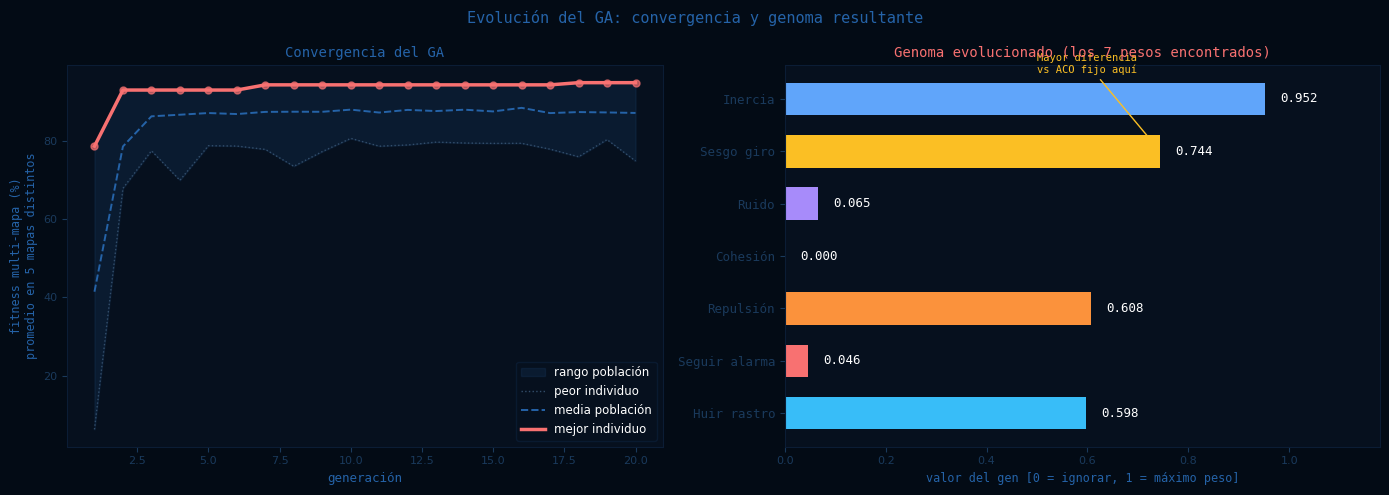


Interpretación del genoma evolucionado:
  Huir rastro           : GA=0.598  ACO=0.700  ≈ similar
  Seguir alarma         : GA=0.046  ACO=0.000  ≈ similar
  Repulsión             : GA=0.608  ACO=0.350  ↑ mayor
  Cohesión              : GA=0.000  ACO=0.000  ≈ similar
  Ruido                 : GA=0.065  ACO=0.500  ↓ menor
  Sesgo giro            : GA=0.744  ACO=0.000  ↑ mayor
  Inercia               : GA=0.952  ACO=0.400  ↑ mayor


In [15]:
# ── Visualizar convergencia + genoma ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("Evolución del GA: convergencia y genoma resultante",
             color=TC, fontsize=11, fontfamily="monospace")

# Panel izquierdo: curva de convergencia
ax1 = axes[0]
sax(ax1)
gens = [h[0] for h in ga_history]
bst  = [h[1] for h in ga_history]
avg  = [h[2] for h in ga_history]
wst  = [h[3] for h in ga_history]

ax1.fill_between(gens, wst, bst, color="#1e4a7a", alpha=0.20, label="rango población")
ax1.plot(gens, wst, color="#334e6b", lw=1.0, ls=":", label="peor individuo")
ax1.plot(gens, avg, color="#2563a8", lw=1.4, ls="--", label="media población")
ax1.plot(gens, bst, color="#f87171", lw=2.5, label="mejor individuo")
for g, b in zip(gens, bst):
    ax1.plot(g, b, "o", color="#f87171", ms=5, alpha=0.7, zorder=5)

ax1.set_xlabel("generación", fontsize=9, fontfamily="monospace")
ax1.set_ylabel(f"fitness multi-mapa (%)\npromedio en {MAPS_PER_EVAL} mapas distintos",
               fontsize=8.5, fontfamily="monospace")
ax1.set_title("Convergencia del GA", color=TC, fontsize=10, fontfamily="monospace")
ax1.legend(fontsize=8.5, facecolor=BG2, labelcolor="white",
           framealpha=0.8, edgecolor=GC, loc="lower right")

# Panel derecho: genoma en barras horizontales
ax2 = axes[1]
sax(ax2)
bars = ax2.barh(range(N_GENES), best_genome, color=GENE_COLORS, height=0.62)
ax2.set_xlim(0, 1.18)
ax2.set_yticks(range(N_GENES))
ax2.set_yticklabels(GENE_NAMES, fontsize=9, fontfamily="monospace")
ax2.set_title("Genoma evolucionado (los 7 pesos encontrados)",
               color="#f87171", fontsize=10, fontfamily="monospace")
ax2.set_xlabel("valor del gen [0 = ignorar, 1 = máximo peso]",
               fontsize=8.5, fontfamily="monospace")
for bar, v in zip(bars, best_genome):
    ax2.text(v + 0.03, bar.get_y() + bar.get_height()/2, f"{v:.3f}",
              va="center", color="white", fontsize=9, fontfamily="monospace")

# Comparar con ACO fijo
ax2.barh(np.arange(N_GENES) + 0.0, ACO_GENOME,
          height=0.0, color="none")  # invisible, solo para referencia
# marcar diferencias clave
diffs = np.abs(best_genome - ACO_GENOME)
max_diff_idx = int(np.argmax(diffs))
ax2.annotate(f"Mayor diferencia\nvs ACO fijo aquí",
              xy=(best_genome[max_diff_idx], max_diff_idx),
              xytext=(0.5, max_diff_idx + 1.5),
              color="#fbbf24", fontsize=7.5, fontfamily="monospace",
              arrowprops=dict(arrowstyle="->", color="#fbbf24", lw=1.0))

plt.tight_layout()
plt.show()

# Imprimir interpretación
print("\nInterpretación del genoma evolucionado:")
for n, v_ga, v_aco in zip(GENE_NAMES, best_genome, ACO_GENOME):
    diff = v_ga - v_aco
    signo = "↑ mayor" if diff > 0.15 else ("↓ menor" if diff < -0.15 else "≈ similar")
    print(f"  {n:<22}: GA={v_ga:.3f}  ACO={v_aco:.3f}  {signo}")


In [16]:
# Genoma aleatorio = baseline mínimo
rnd_genome = np.array([0.1, 0.0, 0.0, 0.0, 1.0, 0.0, 0.1])

val_results = {"ga": [], "aco": [], "rnd": []}

print(f"{'═'*58}")
print(f"  VALIDACIÓN — {len(TEST_SEEDS)} mapas NUNCA vistos")
print(f"  (seeds {TEST_SEEDS[0]}–{TEST_SEEDS[-1]})")
print(f"{'═'*58}")
print(f"  {'seed':>6}  {'GA':>8}  {'ACO':>8}  {'Rand':>8}  {'GA vs ACO':>10}")

for ts in TEST_SEEDS:
    def ev(gn):
        cc, cv, _ = simulate(gn, ts, sim_seed=7)
        return cc[-1] * 0.55 + cv[-1] * 0.45

    fg = ev(best_genome)
    fa = ev(ACO_GENOME)
    fr = ev(rnd_genome)
    val_results["ga"].append(fg)
    val_results["aco"].append(fa)
    val_results["rnd"].append(fr)

    marca = "✓" if fg > fa else "✗"
    print(f"  {ts:>6}  {fg:>7.1f}%  {fa:>7.1f}%  {fr:>7.1f}%  "
          f"  {marca}  {fg-fa:>+.1f}pp")

print(f"\n{'─'*58}")
for name in ["ga", "aco", "rnd"]:
    arr = np.array(val_results[name])
    wins = sum(1 for g, a in zip(val_results["ga"], val_results["aco"]) if g > a)
    print(f"  {LBL[name]:<35}  μ={arr.mean():.1f}%  σ={arr.std():.1f}%")
print(f"\n  GA gana en {wins}/{len(TEST_SEEDS)} mapas")
print(f"  σ del GA = {np.array(val_results['ga']).std():.1f}% → baja varianza = comportamiento robusto")


══════════════════════════════════════════════════════════
  VALIDACIÓN — 15 mapas NUNCA vistos
  (seeds 600–901)
══════════════════════════════════════════════════════════
    seed        GA       ACO      Rand   GA vs ACO
     600     93.3%     60.6%     32.3%    ✓  +32.7pp
     650     90.5%     76.9%     41.8%    ✓  +13.6pp
     700     94.5%     67.5%     22.2%    ✓  +27.0pp
     750     95.2%     64.6%     45.5%    ✓  +30.6pp
     800     93.0%     67.8%     17.8%    ✓  +25.2pp
     850     92.2%     58.1%     33.3%    ✓  +34.1pp
     900     89.8%     60.1%     29.2%    ✓  +29.7pp
     950     89.8%     66.6%     32.1%    ✓  +23.2pp
     601     86.0%     82.5%     47.5%    ✓  +3.6pp
     651     93.0%     79.1%     46.0%    ✓  +13.9pp
     701     94.2%     70.5%     29.4%    ✓  +23.7pp
     751     91.4%     76.5%     23.7%    ✓  +14.9pp
     801     87.9%     66.5%     33.8%    ✓  +21.4pp
     851     84.9%     69.8%     39.6%    ✓  +15.1pp
     901     91.7%     55.7%     33

In [17]:
def draw_snap(ax, snap, dcol, tcol):
    """Dibuja un frame de la simulación."""
    ax.set_facecolor("#040b14")
    for sp in ax.spines.values(): sp.set_color(tcol + "44")
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(snap["grid"], cmap=plt.cm.Greys, origin="lower",
              vmin=0, vmax=1, alpha=0.45, zorder=1)
    ax.imshow(np.minimum(snap["cov"], 5)/5, origin="lower",
              cmap=TCOV, alpha=0.65, zorder=2)
    if snap["ptr"].max() > 0.1:
        ax.imshow(snap["ptr"]/9, origin="lower", cmap=TCOV, alpha=0.22, zorder=3)
    if snap["pal"].max() > 0.1:
        ax.imshow(snap["pal"]/10, origin="lower", cmap=TALM, alpha=0.45, zorder=4)
    for v in snap["victims"]:
        if v["found"]:
            ax.plot(v["x"], v["y"], "D", color="#22c55e", ms=5.5, mew=0.7, mec="w", zorder=7)
        else:
            ax.plot(v["x"], v["y"], "*", color="#fbbf24", ms=9, mew=0.5, mec="w",
                     zorder=7, alpha=0.85)
    p = snap["pos"]; vv = snap["vel"]
    ax.scatter(p[:, 0], p[:, 1], s=50, c=dcol, zorder=8, edgecolors="w", linewidths=0.5)
    for j in range(len(p)):
        vn = max(np.hypot(vv[j, 0], vv[j, 1]), 1e-6)
        ax.annotate("", xy=(p[j,0]+vv[j,0]/vn*2.8, p[j,1]+vv[j,1]/vn*2.8),
                    xytext=(p[j, 0], p[j, 1]),
                    arrowprops=dict(arrowstyle="->", color=dcol, lw=0.9, alpha=0.55),
                    zorder=9)
    nf  = sum(1 for v in snap["victims"] if v["found"])
    ax.set_title(f"t={snap['t']}  cob={snap['pc']:.0f}%  vic={nf}/{N_VICT}",
                  color=tcol, fontsize=8, fontfamily="monospace", pad=2)


# ── Generar snapshots para dos mapas de test ──────────────────────
SNAP_TIMES = {70, 160, 270, 340}
TMAP1, TMAP2 = 600, 750

snaps_all = {}
for algo, genome in [("ga", best_genome), ("aco", ACO_GENOME)]:
    for ts in [TMAP1, TMAP2]:
        _, _, s = simulate(genome, ts, sim_seed=3, record=True, snap_at=SNAP_TIMES)
        snaps_all[(algo, ts)] = s

# ── Curvas en mapa TMAP1 ──────────────────────────────────────────
curves = {}
for name, genome in [("rnd", rnd_genome), ("aco", ACO_GENOME), ("ga", best_genome)]:
    cvs = []; vvs = []
    for s2 in range(4):
        cc, cv, _ = simulate(genome, TMAP1, sim_seed=s2)
        cvs.append(cc); vvs.append(cv)
    curves[name] = {
        "cm": np.mean(cvs, 0), "cs": np.std(cvs, 0),
        "vm": np.mean(vvs, 0), "vs": np.std(vvs, 0),
    }

print("✓ Simulaciones completadas, generando figura...")

✓ Simulaciones completadas, generando figura...


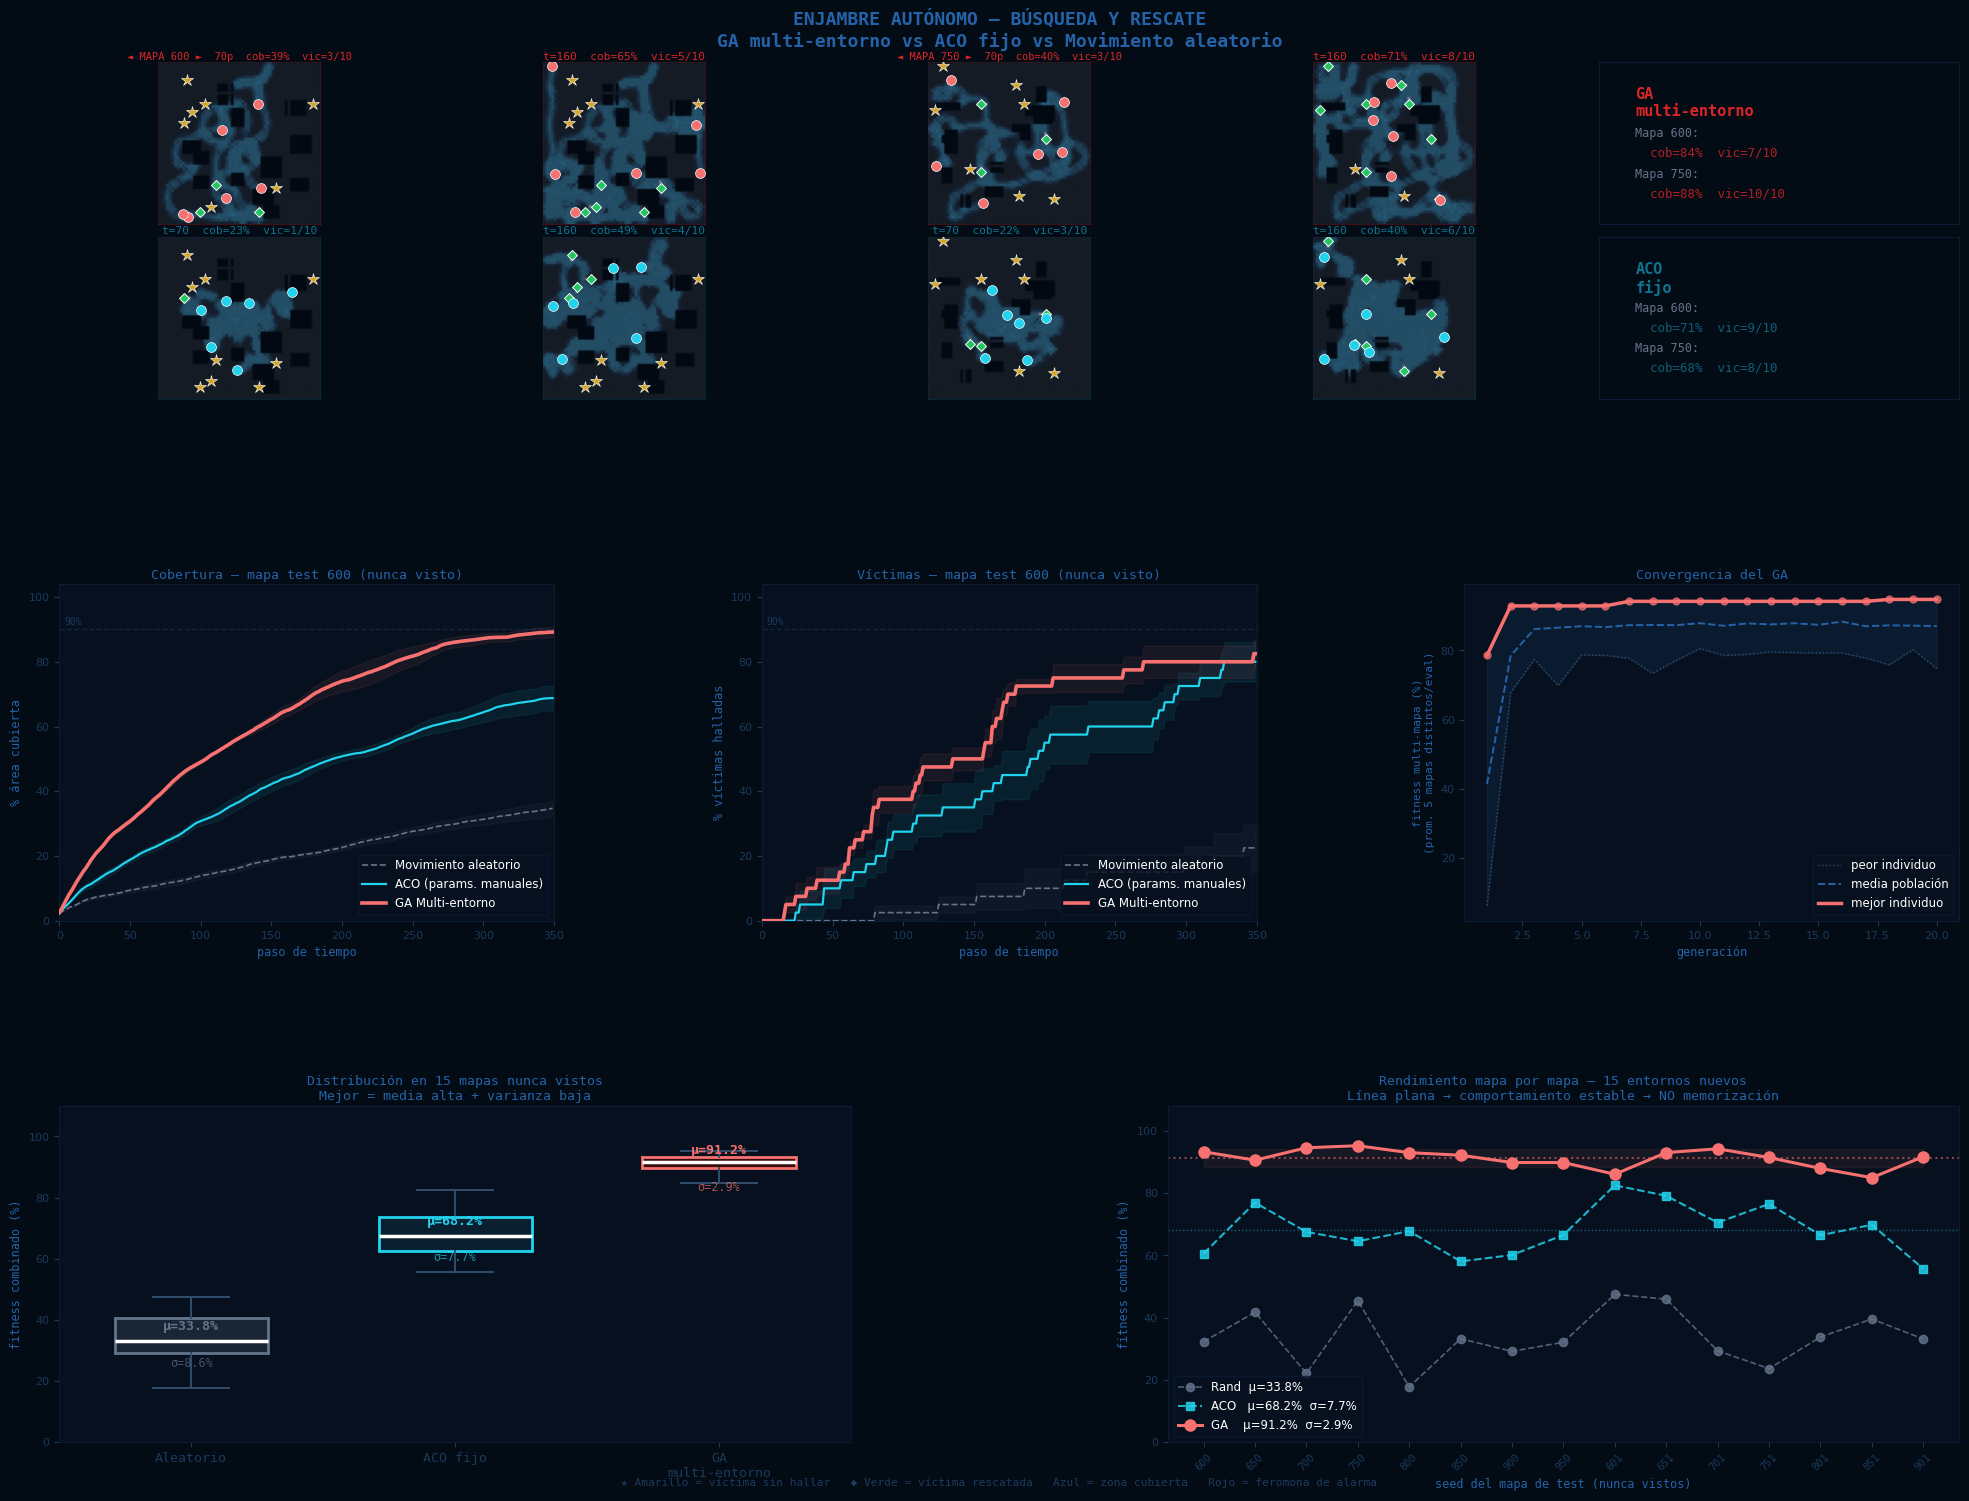

✓ Figura guardada como enjambre_final.png


In [19]:
# ══ FIGURA FINAL: 3 filas ════════════════════════════════════════
fig = plt.figure(figsize=(20, 15), facecolor=BG)
fig.suptitle(
    "ENJAMBRE AUTÓNOMO — BÚSQUEDA Y RESCATE\n"
    "GA multi-entorno vs ACO fijo vs Movimiento aleatorio",
    color=TC, fontsize=13, fontfamily="monospace",
    y=0.995, fontweight="bold"
)

outer = mgs.GridSpec(3, 1, figure=fig,
                      hspace=0.55, top=0.960, bottom=0.04, left=0.03, right=0.98)


# ══ FILA 0: snapshots en dos mapas de test ════════════════════════
row0 = mgs.GridSpecFromSubplotSpec(2, 5, subplot_spec=outer[0],
                                    wspace=0.07, hspace=0.08)

algo_defs = [
    ("ga",  "#f87171", "#dc2626"),
    ("aco", "#22d3ee", "#0e7490"),
]
for ri, (algo, dcol, tcol) in enumerate(algo_defs):
    s1 = snaps_all[(algo, TMAP1)]
    s2 = snaps_all[(algo, TMAP2)]
    mixed = s1[:2] + s2[:2]   # 2 snapshots de cada mapa

    for ci, sn in enumerate(mixed[:4]):
        ax = fig.add_subplot(row0[ri, ci])
        draw_snap(ax, sn, dcol, tcol)
        if ri == 0:
            prefix = f"◄ MAPA {TMAP1} ►" if ci < 2 else f"◄ MAPA {TMAP2} ►"
            if ci in [0, 2]:
                ax.set_title(f"{prefix}  {sn['t']}p  cob={sn['pc']:.0f}%  "
                              f"vic={sum(1 for v in sn['victims'] if v['found'])}/{N_VICT}",
                              color=tcol, fontsize=7.5, fontfamily="monospace", pad=2)

    # Columna 5: resumen
    ax_s = fig.add_subplot(row0[ri, 4])
    ax_s.set_facecolor(BG); ax_s.set_xticks([]); ax_s.set_yticks([])
    for sp in ax_s.spines.values(): sp.set_color(GC)
    fl1 = s1[-1] if s1 else {"pc": 0, "victims": []}
    fl2 = s2[-1] if s2 else {"pc": 0, "victims": []}
    vc1 = sum(1 for v in fl1["victims"] if v["found"])
    vc2 = sum(1 for v in fl2["victims"] if v["found"])
    lbl = "GA\nmulti-entorno" if algo == "ga" else "ACO\nfijo"
    ax_s.text(0.10, 0.85, lbl, color=tcol, fontsize=11, fontweight="bold",
               fontfamily="monospace", transform=ax_s.transAxes, va="top")
    for y2, ms_txt, ts in [(0.60, TMAP1, fl1), (0.35, TMAP2, fl2)]:
        vc = sum(1 for v in ts["victims"] if v["found"])
        ax_s.text(0.10, y2, f"Mapa {ms_txt}:", color="#64748b", fontsize=8.5,
                   fontfamily="monospace", transform=ax_s.transAxes, va="top")
        ax_s.text(0.10, y2-0.12, f"  cob={ts['pc']:.0f}%  vic={vc}/{N_VICT}",
                   color=tcol+"cc", fontsize=9, fontfamily="monospace",
                   transform=ax_s.transAxes, va="top")


# ══ FILA 1: curvas de rendimiento + convergencia GA ═══════════════
row1 = mgs.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[1], wspace=0.42)
ax_c = fig.add_subplot(row1[0, 0])
ax_v = fig.add_subplot(row1[0, 1])
ax_k = fig.add_subplot(row1[0, 2])   # convergencia

T = np.arange(T_MAX)
for name, col, lw, ls in [("rnd", "#64748b", 1.2, "--"),
                             ("aco", "#22d3ee", 1.6, "-"),
                             ("ga",  "#f87171", 2.6, "-")]:
    r = curves[name]
    for ax_p, mk, sk in [(ax_c, "cm", "cs"), (ax_v, "vm", "vs")]:
        sax(ax_p)
        ax_p.plot(T, r[mk], color=col, lw=lw, ls=ls, label=LBL[name],
                   zorder=6 if name == "ga" else 4)
        ax_p.fill_between(T, r[mk] - r[sk]*0.5, r[mk] + r[sk]*0.5,
                           color=col, alpha=0.08)

for ax_p, yl, tit in [
    (ax_c, "% área cubierta", f"Cobertura — mapa test {TMAP1} (nunca visto)"),
    (ax_v, "% víctimas halladas", f"Víctimas — mapa test {TMAP1} (nunca visto)"),
]:
    ax_p.axhline(90, color="#1e3a5f", ls="--", lw=1.0, alpha=0.5)
    ax_p.text(T_MAX*0.01, 91.5, "90%", color="#1e3a5f", fontsize=7,
               fontfamily="monospace")
    ax_p.set_xlim(0, T_MAX); ax_p.set_ylim(0, 104)
    ax_p.set_xlabel("paso de tiempo", fontsize=8.5, fontfamily="monospace")
    ax_p.set_ylabel(yl, fontsize=8.5, fontfamily="monospace")
    ax_p.set_title(tit, color=TC, fontsize=9.5, fontfamily="monospace", pad=4)
    ax_p.legend(fontsize=8.5, facecolor=BG2, labelcolor="white",
                 framealpha=0.8, edgecolor=GC, loc="lower right")

sax(ax_k)
gg  = [h[0] for h in ga_history]
bst_h = [h[1] for h in ga_history]
avg_h = [h[2] for h in ga_history]
wst_h = [h[3] for h in ga_history]
ax_k.fill_between(gg, wst_h, bst_h, color="#1e4a7a", alpha=0.20)
ax_k.plot(gg, wst_h, color="#334e6b", lw=1.0, ls=":", label="peor individuo")
ax_k.plot(gg, avg_h, color="#2563a8", lw=1.4, ls="--", label="media población")
ax_k.plot(gg, bst_h, color="#f87171", lw=2.5, label="mejor individuo")
for g2, b in zip(gg, bst_h):
    ax_k.plot(g2, b, "o", color="#f87171", ms=5, alpha=0.7, zorder=5)
ax_k.set_xlabel("generación", fontsize=8.5, fontfamily="monospace")
ax_k.set_ylabel(f"fitness multi-mapa (%)\n(prom. {MAPS_PER_EVAL} mapas distintos/eval)",
                 fontsize=8, fontfamily="monospace")
ax_k.set_title("Convergencia del GA", color=TC, fontsize=9.5,
                fontfamily="monospace", pad=4)
ax_k.legend(fontsize=8.5, facecolor=BG2, labelcolor="white",
             framealpha=0.8, edgecolor=GC)


# ══ FILA 2: distribución y generalización en 15 mapas ═════════════
row2 = mgs.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.40)
ax_box = fig.add_subplot(row2[0, 0])
ax_sct = fig.add_subplot(row2[0, 1])

ga_arr  = np.array(val_results["ga"])
aco_arr = np.array(val_results["aco"])
rnd_arr = np.array(val_results["rnd"])

# Boxplot
sax(ax_box)
bp = ax_box.boxplot(
    [rnd_arr, aco_arr, ga_arr],
    patch_artist=True, widths=0.58,
    medianprops=dict(color="white", lw=2.5),
    whiskerprops=dict(color="#334e6b", lw=1.4),
    capprops=dict(color="#334e6b", lw=1.4),
    flierprops=dict(marker="o", markerfacecolor="#f87171", ms=6),
)
for patch, ec, fc in zip(bp["boxes"],
                          ["#64748b", "#22d3ee", "#f87171"],
                          ["#1a2535", "#0a2030", "#3a0d0d"]):
    patch.set_facecolor(fc); patch.set_edgecolor(ec); patch.set_linewidth(2)

ax_box.set_xticks([1, 2, 3])
ax_box.set_xticklabels(["Aleatorio", "ACO fijo", "GA\nmulti-entorno"],
                         fontsize=9.5, fontfamily="monospace")
ax_box.set_ylabel("fitness combinado (%)", fontsize=8.5, fontfamily="monospace")
ax_box.set_title(f"Distribución en {len(TEST_SEEDS)} mapas nunca vistos\n"
                  "Mejor = media alta + varianza baja",
                  color=TC, fontsize=9.5, fontfamily="monospace", pad=4)
ax_box.set_ylim(0, 110)
for xi, arr, col in [(1, rnd_arr, "#64748b"), (2, aco_arr, "#22d3ee"), (3, ga_arr, "#f87171")]:
    ax_box.text(xi, arr.mean() + 3, f"μ={arr.mean():.1f}%", ha="center",
                 color=col, fontsize=9.5, fontfamily="monospace", fontweight="bold")
    ax_box.text(xi, arr.mean() - 9, f"σ={arr.std():.1f}%", ha="center",
                 color=col + "aa", fontsize=8.5, fontfamily="monospace")

# Scatter línea por mapa
sax(ax_sct)
xs = np.arange(len(TEST_SEEDS))
ax_sct.plot(xs, rnd_arr, "o--", color="#64748b", lw=1.2, ms=6, alpha=0.8,
             label=f"Rand  μ={rnd_arr.mean():.1f}%")
ax_sct.plot(xs, aco_arr, "s--", color="#22d3ee", lw=1.5, ms=6, alpha=0.85,
             label=f"ACO   μ={aco_arr.mean():.1f}%  σ={aco_arr.std():.1f}%")
ax_sct.plot(xs, ga_arr,  "o-",  color="#f87171", lw=2.2, ms=8, zorder=5,
             label=f"GA    μ={ga_arr.mean():.1f}%  σ={ga_arr.std():.1f}%")
ax_sct.fill_between(xs, ga_arr.mean()-ga_arr.std(), ga_arr.mean()+ga_arr.std(),
                     color="#f87171", alpha=0.08)
ax_sct.axhline(ga_arr.mean(),  color="#f87171", ls=":", lw=1.5, alpha=0.55)
ax_sct.axhline(aco_arr.mean(), color="#22d3ee", ls=":", lw=1.0, alpha=0.45)
ax_sct.set_xticks(xs)
ax_sct.set_xticklabels([str(s) for s in TEST_SEEDS],
                         rotation=45, fontsize=7.5, fontfamily="monospace")
ax_sct.set_ylim(0, 108)
ax_sct.set_xlabel("seed del mapa de test (nunca vistos)", fontsize=8.5, fontfamily="monospace")
ax_sct.set_ylabel("fitness combinado (%)", fontsize=8.5, fontfamily="monospace")
ax_sct.set_title(f"Rendimiento mapa por mapa — {len(TEST_SEEDS)} entornos nuevos\n"
                  "Línea plana → comportamiento estable → NO memorización",
                  color=TC, fontsize=9.5, fontfamily="monospace", pad=4)
ax_sct.legend(fontsize=8.5, facecolor=BG2, labelcolor="white",
               framealpha=0.8, edgecolor=GC)

fig.text(0.5, 0.01,
         "★ Amarillo = víctima sin hallar   ◆ Verde = víctima rescatada   "
         "Azul = zona cubierta   Rojo = feromona de alarma",
         ha="center", va="bottom", fontsize=8, fontfamily="monospace", color="#1e3a5f")

plt.savefig("enjambre_final.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()
print("✓ Figura guardada como enjambre_final.png")